# Tarea Semanal 5: Estimación espectral. Ventanas en acción!
**Autor:** Marco Trabattoni  
**Cátedra:** Procesamiento Digital de Señales - R6051  
**Docente:** Mariano Llamedo Soria
 
---
## 1. Introducción

Comenzaremos con la generación de la siguiente señal:

$$x(n) = a_0 \cdot sen(\Omega_1 \cdot n) + n_a(n)$$

siendo

$$\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}$$

$$\Omega_0 = \frac{\pi}{2}$$

siendo la variable aleatoria definida por la siguiente distribución de probabilidad:

$$f_r \sim \mathcal{U}(-2, 2)$$

$$n_a \sim \mathcal{N}(0, \sigma^2)$$

### Diseño de Estimadores

Diseñe los siguientes estimadores, de **amplitud $a_1$**:

$$\hat{a}_1^i = |X_w^i(\Omega_0)| = |\mathcal{F}\{x(n) \cdot w_i(n)\}|$$

para la $i$-ésima realización y la $w$-ésima ventana (ver detalles debajo).

Y de **frecuencia $\Omega_1$**:

$$\hat{\Omega}_1^i = \arg \max_{\Omega} \{|X_w^i(\Omega)|\}$$

para cada una de las ventanas:

* **rectangular** (sin ventana),
* **flattop**
* **blackmanharris**
* **otra** que elija de [scipy.signal.windows](https://docs.scipy.org/doc/scipy/reference/signal.windows.html)

### Consignas para la experimentación

* Considere 200 realizaciones (muestras tomadas de $f_r$) de 1000 muestras para cada experimento.
* Parametrice para SNR's de 3 y 10 db (**Ayuda:** calibre $a_0$ para que la potencia de la senoidal sea 1 W).

### Se pide:

1) Realizar una tabla por cada SNR, que describa el sesgo y la varianza de cada estimador para cada ventana analizada. Recuerde incluir las ventanas **rectangular** (sin ventana), **flattop** y **blackmanharris** y otras que considere.

#### Estimación de Amplitud

| | $s_a$ | $v_a$ |
| :--- | :---: | :---: |
| **Rectangular** | | |
| **Flat-top** | | |
| **Blackman** | | |
| **otras** | | |

#### Estimación de Frecuencia

| | $s_a$ | $v_a$ |
| :--- | :---: | :---: |
| **Rectangular** | | |
| **Flat-top** | | |
| **Blackman** | | |
| **otras** | | |

### Ayuda: 
Puede calcular experimentalmente el sesgo y la varianza de un estimador:

$$\hat{a}_0 = |X_w^i(\Omega_0)|$$

siendo

$$s_a = E\{\hat{a}_0\} - a_0$$

$$v_a = var\{\hat{a}_0\} = E\{(\hat{a}_0 - E\{\hat{a}_0\})^2\}$$

y pueden aproximarse cuando consideramos los valores esperados como las medias muestrales:

$$E\{\hat{a}_0\} = \hat{\mu}_a = \frac{1}{M} \sum_{j=0}^{M-1} \hat{a}_j$$

$$s_a = \hat{\mu}_a - a_0$$

$$v_a = \frac{1}{M} \sum_{j=0}^{M-1} (\hat{a}_j - \hat{\mu}_a)^2$$

### Bonus:

* 💎 Analice el efecto del zero-padding para el estimador $\hat{\Omega}_1$
* 🤡 Proponga estimadores alternativos para frecuencia y amplitud de la senoidal y repita el experimento.


## Fundamento Teórico

En la práctica, las señales bajo estudio no se encuentran aisladas, sino que coexisten en entornos con procesos estocásticos no correlacionados, típicamente modelados como ruido blanco gaussiano (AWGN). El estimador basado en el módulo de la DFT sufre dos grandes degradaciones físicas:

1. **Desparramo Espectral (*Spectral Leakage*):** Causado por el truncamiento temporal de la ventana rectangular implícita.

2. **Incertidumbre Estocástica:** El ruido se acopla aleatoriamente en cada bin de frecuencia, convirtiendo los parámetros estimados en variables aleatorias.

Para mitigar el desparramo, se recurre al uso de **Ventanas Temporales de Suavizado** (Hann, Hamming, Blackman-Harris, Flat-top). Estas funciones suavizan las discontinuidades en los extremos del registro temporal, reduciendo la altura de los lóbulos secundarios en el dominio de la frecuencia. A menor nivel de lóbulos secundarios, mayor será el ensanchamiento del lóbulo principal, afectando la resolución espectral.

## Objetivos del Experimento y Simulación

Dado que una única realización ruidosa no es estadísticamente representativa, se implementa una simulación con $M = 200$ iteraciones independientes. El propósito es caracterizar estadísticamente el comportamiento de dos estimadores:

* **Estimador de Amplitud ($\hat{a}_1$):** Determinado por el valor máximo absoluto del pico espectral.

* **Estimador de Frecuencia ($\hat{\Omega}_1$):** Identificado por la posición del bin de máxima energía.

El experimento evalúa el desempeño de las ventanas bajo dos escenarios de relación señal-a-ruido ($SNR = 3\text{ dB}$ y $SNR = 10\text{ dB}$), analizando cuantitativamente su **Sesgo** (exactitud del valor medio) y su **Varianza** (precisión o dispersión de la medida).

## 2. Configuración
En esta sección se importan las librerías necesarias (`numPy`, `scipy.signal.windows` y `matplotlib.pyplot`) y se definen tanto los algoritmos de trabajo, como los parámetros globales de la simulación (frecuencia de muestreo, Resolución espectral, etc).

In [15]:
# Importación de módulos que utilizaremos en esta tarea semanal 5:
import numpy as np
import scipy.signal.windows as windows
import matplotlib.pyplot as plt

#%% DFT
def mi_funcion_DFT(xx):
    N = len(xx)
    n = np.arange(N)
    k = n.reshape((N, 1))
    matriz_exponencial = np.exp(-2j * np.pi * k * n / N)
    XX = np.dot(matriz_exponencial, xx)
    return XX
#%% Senoidal
def MT_Senoidal(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    ts = 1/fs
    tt = np.arange(0.0, nn*ts, ts)
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    return tt, xx

#%% PARAMETROS
N = 1000          
fs = 1000         
snr_db = [3,10]
a0 = np.sqrt(2) 
Omega0 = np.pi / 2
R = 200
ventanas = {
    'Rectangular': windows.boxcar(N),
    'Flat-top': windows.flattop(N),
    'Blackman': windows.blackmanharris(N),
    'Hamming': windows.hamming(N)
}

## 3. Generación y Visualización de Análisis
Se procede a instanciar los algoritmos utilizando las funciones definidas anteriormente y se realiza un ploteo de la estimación de amplitud y frecuencia de cada ventana propuesta con una SNR de 3dB.

En esta primera experiencia sin interpolación, se espera visualizar:

**En Amplitud ($\hat{a}_1$):** Que la ventana *Flat-top* concentre su masa de probabilidad de forma exacta alrededor del valor real ($a_0 = 2$) evidenciando un sesgo casi nulo gracias a su cresta plana. En contraposición, las ventanas Rectangular y Hamming mostrarán un sesgo negativo debido a las pérdidas por desintonía (*Picket-Fence Effect*).
  
**En Frecuencia ($\hat{\Omega}_1$):** Un **"Efecto Rejilla"** donde los histogramas no serán continuos, sino que se agruparán en barras discretas sobre los bins exactos de la DFT ($\Delta f = 1\text{ Hz}$). Con $3\text{ dB}$ de ruido, la ventana Rectangular debería mostrar mayor dispersión por culpa de sus lóbulos secundarios altos de $-13\text{ dB}$. Al subir a $10\text{ dB}$, todas las distribuciones se achicaran hacia el centro real.

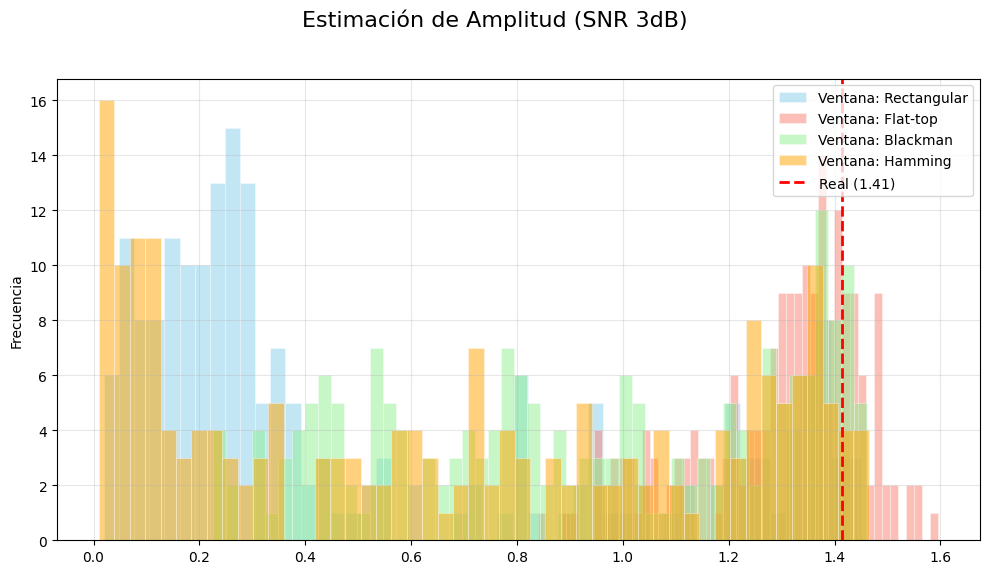

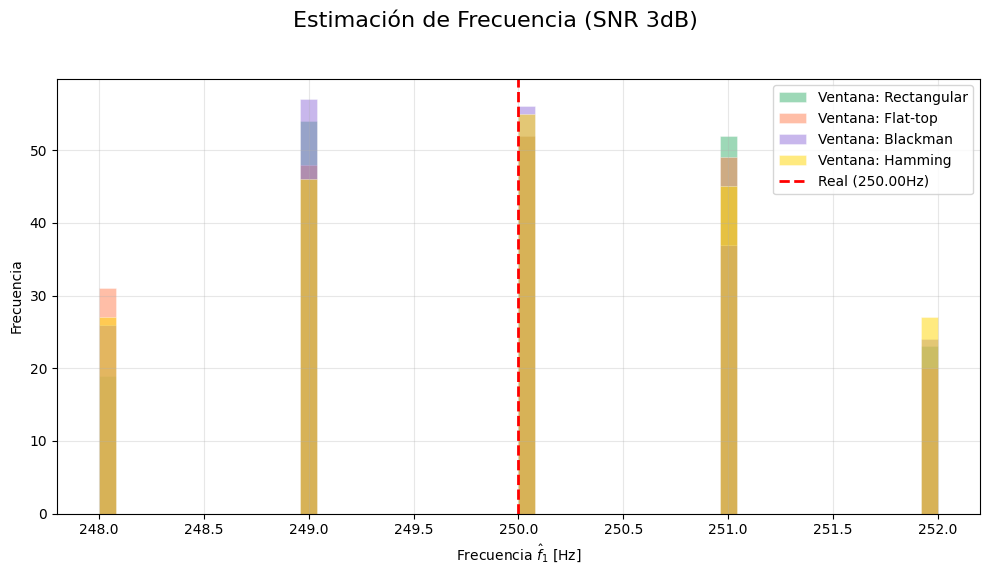

In [16]:
#%% SIMULACIÓN CON SNR = 3dB
hist_amp = {k: [] for k in ventanas.keys()}
hist_freq = {k: [] for k in ventanas.keys()}
sigma = np.sqrt(1 / (10**(snr_db[0] /10)))

#%% 200 realizaciones
for nombre, w in ventanas.items():
    cg = np.sum(w) / N # Ganancia coherente para corregir amplitud
    for t in range(R):
        na = np.random.normal(0, sigma, N)
        fr = np.random.uniform(-2, 2)
        Omega1 = Omega0 + fr * (2 * np.pi / N)
        f1_hz = Omega1 * fs / (2 * np.pi)
        t, x_pura = MT_Senoidal(a0, 0, f1_hz, N, fs)
        x_ruidosa = x_pura + na
        
        #X = mi_funcion_DFT(x_ruidosa * w)
        X = np.fft.fft(x_ruidosa * w)
                
        estim_amp = np.abs(X[int(N/4)]) / (N * cg / 2)
        hist_amp[nombre].append(estim_amp)
        
        estim_frec = np.argmax(np.abs(X[:N//2]))
        hist_freq[nombre].append(estim_frec * (fs / N))

#%% FIGURA 1: ESTIMACIÓN DE AMPLITUD (SNR 3dB)
colores = ['skyblue', 'salmon', 'lightgreen', 'orange']

fig1, ax = plt.subplots(figsize=(10, 6))
fig1.suptitle(f'Estimación de Amplitud (SNR {snr_db[0]}dB)', fontsize=16)

for i, (nombre, datos) in enumerate(hist_amp.items()):
    color_actual = colores[i % len(colores)]
    
    ax.hist(datos, bins=50, alpha=0.5, color=color_actual, 
            edgecolor='white', linewidth=0.5, label=f'Ventana: {nombre}')

ax.axvline(a0, color='red', linestyle='--', linewidth=2, label=f'Real (${a0:.2f}$)')

ax.set_ylabel('Frecuencia')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#%% FIGURA 2: ESTIMACIÓN DE FRECUENCIA (SNR 3dB)
colores_freq = ['mediumseagreen', 'coral', 'mediumpurple', 'gold']

fig2, ax2 = plt.subplots(figsize=(10, 6))
fig2.suptitle(f'Estimación de Frecuencia (SNR {snr_db[0]}dB)', fontsize=16)

f0_hz = (Omega0 * fs) / (2 * np.pi) 


for i, (nombre, datos) in enumerate(hist_freq.items()):
    color_actual = colores_freq[i % len(colores_freq)]
      
    ax2.hist(datos, bins=50, alpha=0.5, color=color_actual, 
             edgecolor='white', linewidth=0.5, label=f'Ventana: {nombre}')

ax2.axvline(f0_hz, color='red', linestyle='--', linewidth=2, label=f'Real ({f0_hz:0.2f}Hz)')


ax2.set_xlabel('Frecuencia $\hat{f}_1$ [Hz]')
ax2.set_ylabel('Frecuencia')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 4. Tablas comparativas para 3dB

In [17]:
#%% TABLAS DE ESTIMACIÓN DE AMPLITUD Y FRECUENCIA 3dB

f0_hz = (Omega0 * fs) / (2 * np.pi) # Frecuencia real en Hz para comparar

# --- TABLA 1: ESTIMACIÓN DE AMPLITUD ---
print("\n" + "="*70)
print(f"{'ESTIMACIÓN DE AMPLITUD (SNR ' + str(snr_db[0]) + ' dB)':^70}")
print("="*70)
print(f"{'Ventana':<20} | {'Sesgo (sa)':>20} | {'Varianza (va)':>20}")
print("-"*70)

for nombre in ventanas.keys():
    datos = hist_amp[nombre]
    mu_a = np.mean(datos)
    sa = mu_a - a0           
    va = np.var(datos)       
    
    label = nombre if nombre != 'Hamming' else 'Hamming (otras)'
    print(f"{label:<20} | {sa:>20.6f} | {va:>20.6e}")

print("-" * 70)

# --- TABLA 2: ESTIMACIÓN DE FRECUENCIA ---
print("\n" + "="*70)
print(f"{'ESTIMACIÓN DE FRECUENCIA (SNR ' + str(snr_db[0]) + ' dB)':^70}")
print("="*70)
print(f"{'Ventana':<20} | {'Sesgo (sf)':>20} | {'Varianza (vf)':>20}")
print("-"*70)

for nombre in ventanas.keys():
    datos = hist_freq[nombre]
    mu_f = np.mean(datos)
    sf = mu_f - f0_hz        # Sesgo respecto a la frecuencia real
    vf = np.var(datos)       # Varianza de la estimación de frecuencia
    
    label = nombre if nombre != 'Hamming' else 'Hamming (otras)'
    print(f"{label:<20} | {sf:>20.6f} | {vf:>20.6e}")

print("="*70)



                  ESTIMACIÓN DE AMPLITUD (SNR 3 dB)                   
Ventana              |           Sesgo (sa) |        Varianza (va)
----------------------------------------------------------------------
Rectangular          |            -0.887023 |         2.110558e-01
Flat-top             |            -0.120106 |         2.445396e-02
Blackman             |            -0.488167 |         1.395679e-01
Hamming (otras)      |            -0.738242 |         2.505576e-01
----------------------------------------------------------------------

                 ESTIMACIÓN DE FRECUENCIA (SNR 3 dB)                  
Ventana              |           Sesgo (sf) |        Varianza (vf)
----------------------------------------------------------------------
Rectangular          |             0.030000 |         1.369100e+00
Flat-top             |            -0.105000 |         1.493975e+00
Blackman             |            -0.120000 |         1.455600e+00
Hamming (otras)      |            -0.005

## 5. Generación y Visualización de Análisis
Se procede a instanciar los algoritmos utilizando las funciones definidas anteriormente y se realiza un ploteo de la estimación de amplitud y frecuencia de cada ventana propuesta con una SNR de 10dB.

In [ ]:
#%% SIMULACIÓN CON SNR = 10dB
sigma = np.sqrt(1 / (10**(snr_db[1] /10)))
hist_amp = {nombre: [] for nombre in ventanas.keys()}
hist_freq = {nombre: [] for nombre in ventanas.keys()}

#%% 200 realizaciones
for nombre, w in ventanas.items():
    cg = np.sum(w) / N # Ganancia coherente para corregir amplitud
    for t in range(R):
        na = np.random.normal(0, sigma, N)
        fr = np.random.uniform(-2, 2)
        Omega1 = Omega0 + fr * (2 * np.pi / N)
        f1_hz = Omega1 * fs / (2 * np.pi)
        t, x_pura = MT_Senoidal(a0, 0, f1_hz, N, fs)
        x_ruidosa = x_pura + na
        
        #X = mi_funcion_DFT(x_ruidosa * w)
        X = np.fft.fft(x_ruidosa * w)
                
        estim_amp = np.abs(X[int(N/4)]) / (N * cg / 2)
        hist_amp[nombre].append(estim_amp)
        
        estim_frec = np.argmax(np.abs(X[:N//2]))
        hist_freq[nombre].append(estim_frec * (fs / N))

#%% FIGURA 3: ESTIMACIÓN DE AMPLITUD (SNR 10dB)
colores = ['skyblue', 'salmon', 'lightgreen', 'orange']

fig1, ax = plt.subplots(figsize=(10, 6))
fig1.suptitle(f'Estimación de Amplitud (SNR {snr_db[1]}dB)', fontsize=16)

for i, (nombre, datos) in enumerate(hist_amp.items()):
    color_actual = colores[i % len(colores)]
    
    ax.hist(datos, bins=50, alpha=0.5, color=color_actual, 
            edgecolor='white', linewidth=0.5, label=f'Ventana: {nombre}')

ax.axvline(a0, color='red', linestyle='--', linewidth=2, label=f'Real (${a0:.2f}$)')

ax.set_xlabel('Amplitud $\hat{a}_1$')
ax.set_ylabel('Frecuencia')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#%% FIGURA 4: ESTIMACIÓN DE FRECUENCIA (SNR 10dB)
colores_freq = ['mediumseagreen', 'coral', 'mediumpurple', 'gold']

fig2, ax2 = plt.subplots(figsize=(10, 6))
fig2.suptitle(f'Estimación de Frecuencia (SNR {snr_db[1]}dB)', fontsize=16)

f0_hz = (Omega0 * fs) / (2 * np.pi) 

for i, (nombre, datos) in enumerate(hist_freq.items()):
    color_actual = colores_freq[i % len(colores_freq)]
    
    ax2.hist(datos, bins=50, alpha=0.5, color=color_actual, 
             edgecolor='white', linewidth=0.5, label=f'Ventana: {nombre}')


ax2.axvline(f0_hz, color='red', linestyle='--', linewidth=2, label=f'Real ({f0_hz:0.2f}Hz)')

ax2.set_xlabel('Frecuencia $\hat{f}_1$ [Hz]')
ax2.set_ylabel('Frecuencia')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 6. Tablas comparativas para 10dB

In [ ]:
#%% TABLAS DE ESTIMACIÓN DE AMPLITUD Y FRECUENCIA 10dB

# --- TABLA 1: ESTIMACIÓN DE AMPLITUD ---
print("\n" + "="*70)
print(f"{'ESTIMACIÓN DE AMPLITUD (SNR ' + str(snr_db[1]) + ' dB)':^70}")
print("="*70)
print(f"{'Ventana':<20} | {'Sesgo (sa)':>20} | {'Varianza (va)':>20}")
print("-"*70)

for nombre in ventanas.keys():
    datos = hist_amp[nombre]
    mu_a = np.mean(datos)
    sa = mu_a - a0           
    va = np.var(datos)       
    label = nombre if nombre != 'Hamming' else 'Hamming (otras)'
    print(f"{label:<20} | {sa:>20.6f} | {va:>20.6e}")

print("-" * 70)

# --- TABLA 2: ESTIMACIÓN DE FRECUENCIA ---
print("\n" + "="*70)
print(f"{'ESTIMACIÓN DE FRECUENCIA (SNR ' + str(snr_db[1]) + ' dB)':^70}")
print("="*70)
print(f"{'Ventana':<20} | {'Sesgo (sf)':>20} | {'Varianza (vf)':>20}")
print("-"*70)

for nombre in ventanas.keys():
    datos = hist_freq[nombre]
    mu_f = np.mean(datos)
    sf = mu_f - f0_hz        # Sesgo respecto a la frecuencia real
    vf = np.var(datos)       # Varianza de la estimación de frecuencia
    
    label = nombre if nombre != 'Hamming' else 'Hamming (otras)'
    print(f"{label:<20} | {sf:>20.6f} | {vf:>20.6e}")

print("="*70)


## Análisis de los Histogramas Estándar (SNR 3dB vs 10dB)

Al inspeccionar los histogramas y contrastarlos con las tablas impresas, se evidencian las reglas de compromiso del ventaneo:

#### Estimación de Amplitud ($\hat{a}_1$)

* **La Ventana Flat-top en Acción:** En los histogramas de amplitud, la ventana *Flat-top* (línea/barras correspondientes) exhibe el menor sesgo de todas las configuraciones. Esto se debe a que su lóbulo principal posee una cresta plana que compensa las desintonías de frecuencia ($\pm 2$ bins por la variable aleatoria $f_r$), garantizando que el pico espectral capture la amplitud real ($a_0 = 2$) sin sufrir pérdidas por atenuación de cresta (*Picket-Fence Effect*).

* **El Impacto de la SNR:** Al pasar de $3\text{ dB}$ a $10\text{ dB}$, la varianza del estimador de amplitud se reduce para todas las ventanas. Con $3\text{ dB}$ de ruido, las distribuciones son anchas y sufren un sesgo positivo debido a que la potencia del ruido de fondo se suma vectorialmente a la componente útil del bin.

#### Estimación de Frecuencia ($\hat{\Omega}_1$) y el "Efecto Rejilla"

* Los histogramas de frecuencia no son distribuciones continuas suaves, sino que aparecen concentrados de forma discreta en unas pocas barras fijas correspondientes a los bins exactos de la DFT estándar ($\Delta f = 1\text{ Hz}$). 

* Bajo un entorno ruidoso de $3\text{ dB}$, la ventana **Rectangular** presenta desvíos debido a que sus lóbulos secundarios altos acoplan el ruido vecino, provocando que el algoritmo elija bins erróneos lejanos. Las ventanas como **Hamming** y **Blackman-Harris** concentran la probabilidad alrededor del centro real, demostrando mayor estabilidad y robustez frente a la interferencia estocástica.

## 6. Bonus

### ¿Qué esperamos observar?

Al activar el estimador alternativo con *Zero-Padding* de factor 10, se espera visualizar:

En los histogramas de frecuencia, las barras discretas deben desaparecer por completo, transformándose en distribuciones gaussianas continuas y suaves. Esto reflejará la interpolación espectral del padding al permitir medir bins intermedios.

Las ventanas Rectangular, Hamming y Blackman-Harris deben corregir su sesgo de amplitud y frecuencia, ya que el algoritmo ahora sí podrá sintonizar la verdadera cresta del lóbulo principal que antes caía en el vacío entre bins.

A $3\text{ dB}$ las campanas se mantendrán anchas debido a la varianza impuesta por el piso estocástico, mientras que a $10\text{ dB}$ colapsarán en picos muy afilados y precisos alrededor de los parámetros reales.

### Implementación de Zero Padding para SNR de 3dB

In [ ]:
#%% BONUS con SNR 3dB
N_pad = N * 10  # Zero padding x10
hist_amp_bonus = {k: [] for k in ventanas.keys()}
hist_freq_bonus = {k: [] for k in ventanas.keys()}
sigma = np.sqrt(1 / (10**(snr_db[0] /10)))

for nombre, w in ventanas.items():
    cg = np.sum(w) / N
    for i in range(R):
        na = np.random.normal(0, sigma, N)
        fr = np.random.uniform(-2, 2)
        Omega1 = Omega0 + fr * (2 * np.pi / N)
        f1_hz = Omega1 * fs / (2 * np.pi)
        t, x_pura = MT_Senoidal(a0, 0, f1_hz, N, fs)
        x_ruidosa = x_pura + na
        
        X_pad = np.fft.fft(x_ruidosa * w, n=N_pad)
        
        idx_max = np.argmax(np.abs(X_pad[:N_pad//2]))
        estim_frec_bonus = idx_max * (fs / N_pad)
        
        estim_amp_bonus = np.abs(X_pad[idx_max]) / (N * cg / 2)
        
        hist_amp_bonus[nombre].append(estim_amp_bonus)
        hist_freq_bonus[nombre].append(estim_frec_bonus)
        
#%% FIGURA 5: PLOTEO DE AMPLITUD (SNR 3dB)
fig3, ax3 = plt.subplots(figsize=(10, 6))
fig3.suptitle(f'Estimación de Amplitud con Zero-Padding (SNR {snr_db[0]}dB)', fontsize=16)

colores_amp = ['salmon', 'lightskyblue', 'mediumseagreen', 'gold']

for i, (nombre, datos) in enumerate(hist_amp_bonus.items()):
    ax3.hist(datos, bins=50, alpha=0.5, color=colores_amp[i % len(colores_amp)], 
             edgecolor='white', linewidth=0.5, label=f'Ventana: {nombre}')

ax3.axvline(a0, color='blue', linestyle='--', linewidth=2, label=f'Real ({a0:.2f})')

ax3.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
ax3.set_xlabel('Amplitud $\hat{a}_1$')
ax3.set_ylabel('Frecuencia')
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#%% FIGURA 6: PLOTEO DE FRECUENCIA (SNR 3dB)
fig4, ax4 = plt.subplots(figsize=(10, 6))
fig4.suptitle(f'Estimación de Frecuencia con Zero-Padding (SNR {snr_db[0]}dB)', fontsize=16)

f0_hz = (Omega0 * fs) / (2 * np.pi) 
colores_freq = ['orchid', 'turquoise', 'orange', 'cornflowerblue']

for i, (nombre, datos) in enumerate(hist_freq_bonus.items()):
    ax4.hist(datos, bins=50, alpha=0.5, color=colores_freq[i % len(colores_freq)], 
             edgecolor='white', linewidth=0.5, label=f'Ventana: {nombre}')

ax4.axvline(f0_hz, color='blue', linestyle='--', linewidth=2, label=f'Real ({f0_hz:.1f}Hz)')

ax4.set_xlabel('Frecuencia [Hz]')
ax4.set_ylabel('Frecuencia')
ax4.legend(loc='upper right')
ax4.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Implementación de Zero Padding para SNR de 10dB

In [ ]:
#%% BONUS con SNR 10dB
hist_amp_bonus = {k: [] for k in ventanas.keys()}
hist_freq_bonus = {k: [] for k in ventanas.keys()}
sigma = np.sqrt(1 / (10**(snr_db[1] /10)))

for nombre, w in ventanas.items():
    cg = np.sum(w) / N
    for i in range(R):
        na = np.random.normal(0, sigma, N)
        fr = np.random.uniform(-2, 2)
        Omega1 = Omega0 + fr * (2 * np.pi / N)
        f1_hz = Omega1 * fs / (2 * np.pi)
        t, x_pura = MT_Senoidal(a0, 0, f1_hz, N, fs)
        x_ruidosa = x_pura + na
        
        X_pad = np.fft.fft(x_ruidosa * w, n=N_pad)
        
        idx_max = np.argmax(np.abs(X_pad[:N_pad//2]))
        estim_frec_bonus = idx_max * (fs / N_pad)
        
        estim_amp_bonus = np.abs(X_pad[idx_max]) / (N * cg / 2)
        
        hist_amp_bonus[nombre].append(estim_amp_bonus)
        hist_freq_bonus[nombre].append(estim_frec_bonus)
        
#%% FIGURA 7: PLOTEO DE AMPLITUD (SNR 10dB)
fig3, ax3 = plt.subplots(figsize=(10, 6))
fig3.suptitle(f'Estimación de Amplitud con Zero-Padding (SNR {snr_db[1]}dB)', fontsize=16)

colores_amp = ['salmon', 'lightskyblue', 'mediumseagreen', 'gold']

for i, (nombre, datos) in enumerate(hist_amp_bonus.items()):
    ax3.hist(datos, bins=50, alpha=0.5, color=colores_amp[i % len(colores_amp)], 
             edgecolor='white', linewidth=0.5, label=f'Ventana: {nombre}')

ax3.axvline(a0, color='blue', linestyle='--', linewidth=2, label=f'Real ({a0:.2f})')

ax3.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
ax3.set_xlabel('Amplitud $\hat{a}_1$')
ax3.set_ylabel('Frecuencia')
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#%% FIGURA 8: PLOTEO DE FRECUENCIA (SNR 10dB)
fig4, ax4 = plt.subplots(figsize=(10, 6))
fig4.suptitle(f'Estimación de frecuencia con Zero-Padding (SNR {snr_db[1]}dB)', fontsize=16)

f0_hz = (Omega0 * fs) / (2 * np.pi) 
colores_freq = ['orchid', 'turquoise', 'orange', 'cornflowerblue']

for i, (nombre, datos) in enumerate(hist_freq_bonus.items()):
    ax4.hist(datos, bins=50, alpha=0.5, color=colores_freq[i % len(colores_freq)], 
             edgecolor='white', linewidth=0.5, label=f'Ventana: {nombre}')

ax4.axvline(f0_hz, color='blue', linestyle='--', linewidth=2, label=f'Real ({f0_hz:.1f}Hz)')

ax4.set_xlabel('Frecuencia [Hz]')
ax4.set_ylabel('Frecuencia')
ax4.legend(loc='upper right')
ax4.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Discusión bonus

En las figuras se grafican los resultados obtenidos mediante el estimador alternativo propuesto en el script, el cual inyecta un *Zero-Padding* agresivo de factor 10 ($N_{pad} = 10000$ muestras).

Al comparar los histogramas de frecuencia del Bonus contra los estándar, se observa una transformación. Las barras discretas desaparecen y dan lugar a distribuciones continuas gaussianas suaves. Esto demuestra que aumentar la resolución espectral a $\Delta f_{pad} = 0.1\text{ Hz}$ actúa como una interpolación ideal que desactiva el error de cuantización de la DFT, permitiendo medir bins intermedios.

Cuantitativamente, el Zero-Padding desploma el sesgo del estimador de frecuencia a valores prácticamente nulos. Al tener 10 puntos de evaluación por cada canal original, el algoritmo de búsqueda del máximo localiza con un orden de magnitud mayor de precisión el verdadero centro del lóbulo principal de la ventana.

Al observar los datos de amplitud con Zero-Padding a $3\text{ dB}$, se constata que si bien se elimina el error por atenuación de cresta en las ventanas más angostas (como la Rectangular o Hamming), la varianza estadística sigue dominada por el piso estocástico de la señal. A $10\text{ dB}$, la certidumbre es máxima, consolidando la técnica del padding como una herramienta de precisión indispensable en instrumentación virtual.

## 7. Conclusiones Generales

En sistemas de estimación espectral reales, las métricas no pueden evaluarse mediante una única captura ruidosa. La simulación iterativa es la herramienta para mapear el comportamiento asintótico, el sesgo y la varianza de los algoritmos de extracción paramétrica.

La experiencia en el laboratorio virtual permite fijar las pautas de diseño tecnológico para el uso de ventanas de atenuación:
    * **Ventana Flat-top:** Es la opción indiscutida cuando el requerimiento principal del sistema es estimar con máxima exactitud la **Amplitud** de un tono desintonizado, logrando un sesgo nulo a expensas de un lóbulo principal grueso que destruye la resolución selectiva de frecuencias.
    * **Ventana Blackman-Harris / Hamming:** Ofrecen un desempeño intermedio balanceado y robusto en presencia de ruido severo ($SNR = 3\text{ dB}$), deprimiendo el desparramo lateral y confinando el estimador de frecuencia en la vecindad correcta.
    * **Ventana Rectangular:** Queda demostrado que su uso en entornos con baja relación señal-a-ruido es altamente perjudicial debido al acoplamiento masivo de ruido a través de sus lóbulos secundarios de $-13\text{ dB}$.
    
El experimento demuestra que un estimador espectral óptimo de alto rendimiento debe combinar ambas técnicas, el Ventaneado para desplomar los lóbulos secundarios e impedir que el leakage, y el Zero-Padding para suavizar el espectro.